# Task 2: Exploratory Data Analysis
Ethiopia Financial Inclusion Forecasting

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
from src import data_loader, data_explorer, eda_prep, eda_visuals, eda_correlation

data = data_loader.load_all()
main_df = data["main"]
impact_df = data["impact"]

Loaded 'ethiopia_fi_unified_data': 43 rows, 34 columns
Loaded 'Impact_sheet': 14 rows, 35 columns
Loaded reference codes: 71 rows, 4 columns


## 1. Dataset Overview

In [2]:
data_explorer.summarize(main_df)

=== Record Type Counts ===
record_type
observation    30
event          10
target          3
Name: count, dtype: int64

=== Pillar Counts (NaN = events) ===
pillar
ACCESS           16
USAGE            11
NaN              10
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

=== Confidence Counts ===
confidence
high      40
medium     3
Name: count, dtype: int64

=== Temporal Range ===
Earliest: 2014-12-31 00:00:00 | Latest: 2030-12-31 00:00:00

=== Indicator Coverage ===
indicator
Account Ownership Rate               6
Fayda Digital ID Enrollment          3
4G Population Coverage               2
P2P Transaction Count                2
Account Ownership Gender Gap         2
Mobile Money Account Rate            2
M-Pesa Registered Users              1
Female Mobile Money Account Share    1
Data Affordability Index             1
Mobile Money Activity Rate           1
M-Pesa 90-Day Active Users           1
P2P/ATM Crossover Ratio              1
Telebirr Transaction Value    

In [3]:
print("Source Type Counts")
print(data_explorer.count_by_column(main_df, "source_type"))

Source Type Counts
source_type
operator      15
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64


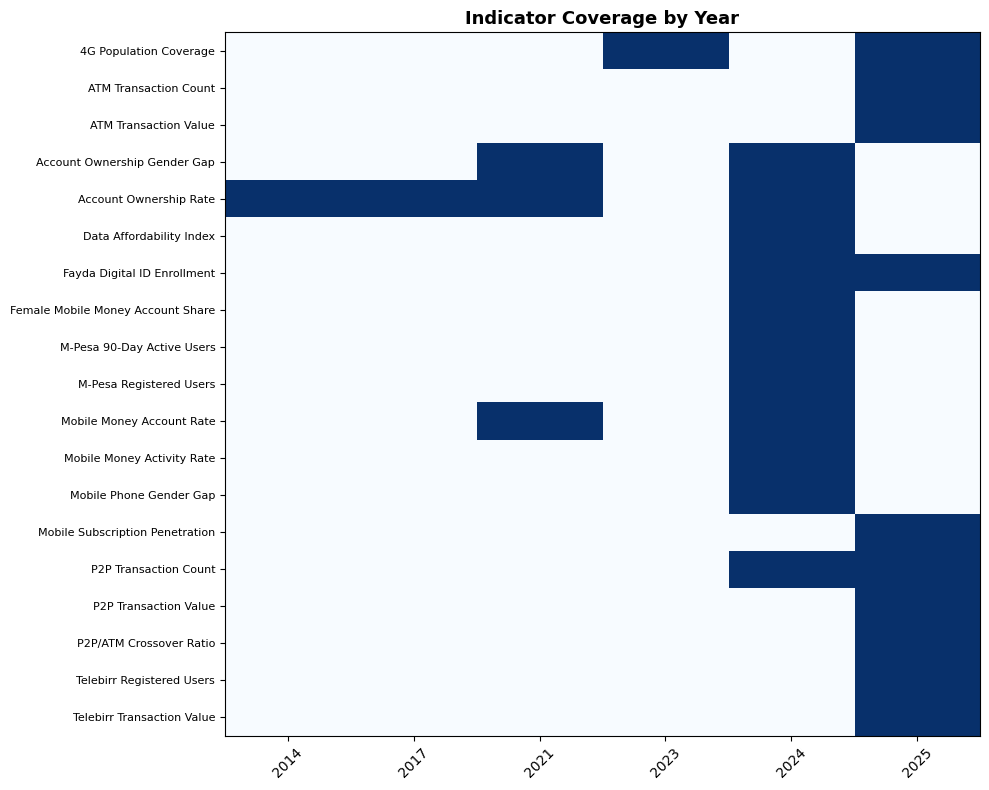

In [4]:
fig = eda_visuals.plot_coverage_heatmap(main_df)

## 2. Access Analysis
### Account Ownership Trajectory (2011-2024)

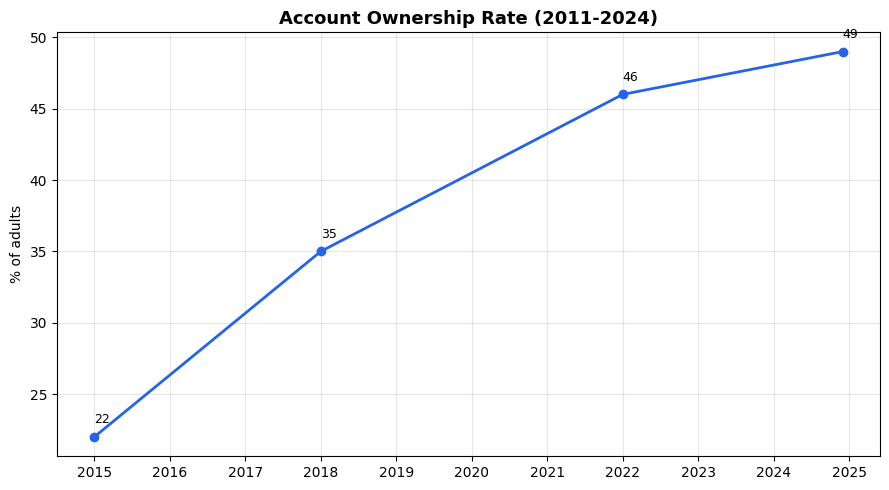

In [5]:
acc_series = eda_prep.get_indicator_series(main_df, "ACC_OWNERSHIP")
acc_series = eda_prep.resolve_duplicate_dates(acc_series)
acc_growth = eda_prep.calculate_growth(acc_series)

fig1 = eda_visuals.plot_indicator_trend(
    acc_series, "Account Ownership Rate (2011-2024)", "% of adults")

#### Growth rate Chart

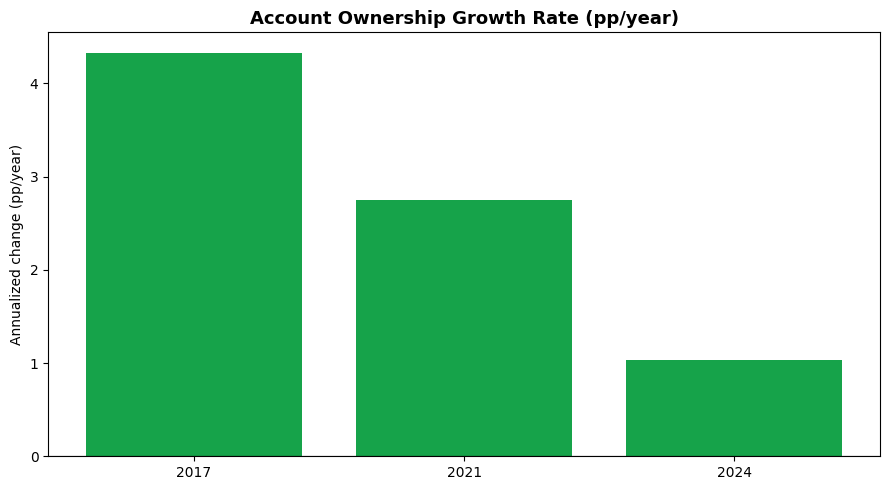

In [6]:
fig2 = eda_visuals.plot_growth_rates(acc_growth, "Account Ownership Growth Rate (pp/year)")

**Observation:** Growth dropped from ~2.75 pp/year (2017-2021) to ~1.03 pp/year
(2021-2024) — a clear deceleration, despite Telebirr and M-Pesa both launching
in this window. This directly addresses the brief's question about the
2021-2024 slowdown.

### 3.Usage (Digital payments) Analysis

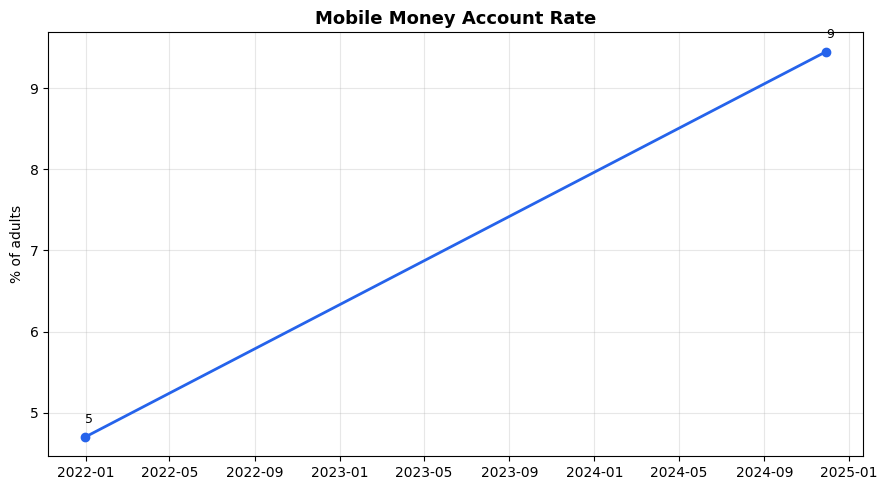

In [7]:
mm_series = eda_prep.get_indicator_series(main_df, "ACC_MM_ACCOUNT")
mm_series = eda_prep.resolve_duplicate_dates(mm_series)
fig3 = eda_visuals.plot_indicator_trend(
    mm_series, "Mobile Money Account Rate", "% of adults")

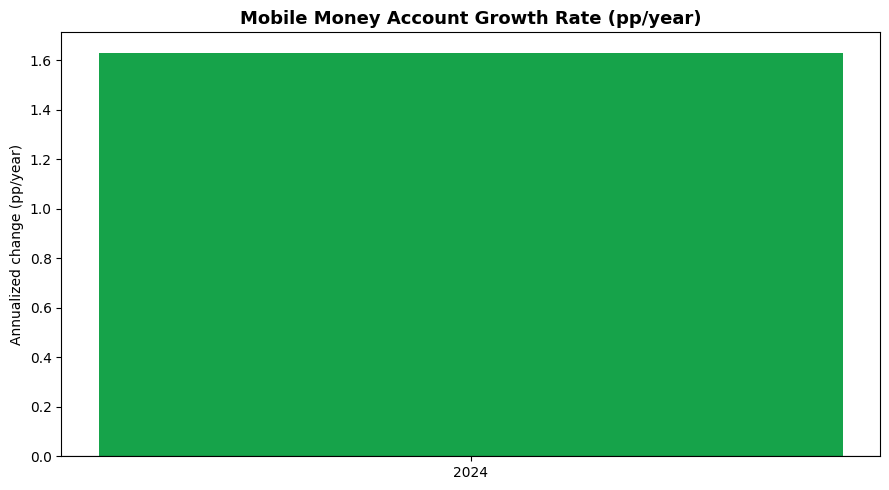

In [12]:
mm_deduped = eda_prep.resolve_duplicate_dates(mm_series)
mm_growth = eda_prep.calculate_growth(mm_deduped)
fig_usage_growth = eda_visuals.plot_growth_rates(mm_growth, "Mobile Money Account Growth Rate (pp/year)")

## 4. Infrastructure and Enablers

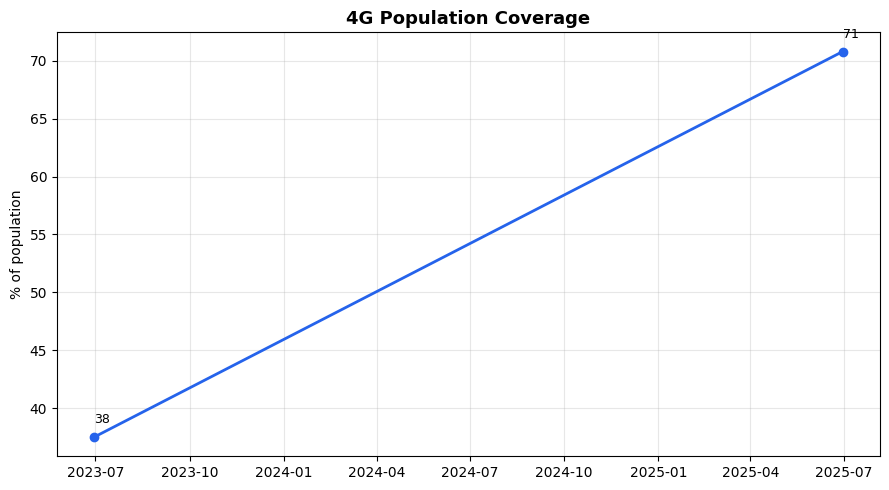

In [8]:
g4_series = eda_prep.get_indicator_series(main_df, "ACC_4G_COV")
fig4 = eda_visuals.plot_indicator_trend(
    g4_series, "4G Population Coverage", "% of population")

## 5. Event Timeline and Overlay

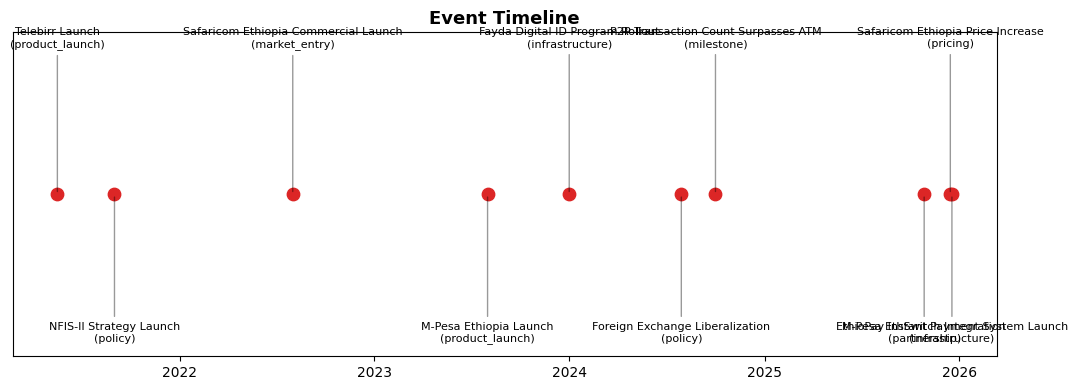

In [9]:
events = main_df[main_df["record_type"] == "event"].copy()
events["observation_date"] = pd.to_datetime(events["observation_date"])
fig5 = eda_visuals.plot_event_timeline(events)

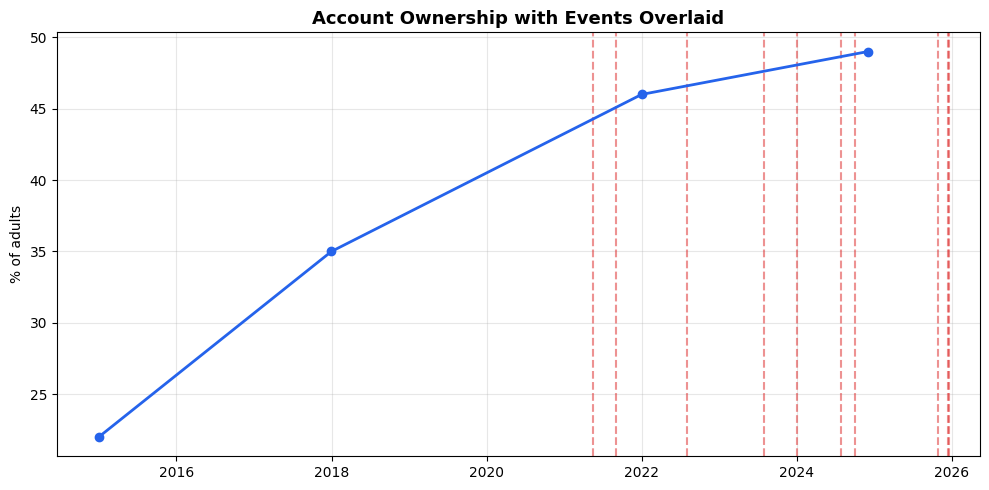

In [10]:
fig6 = eda_visuals.plot_trend_with_events(
    acc_series, events,
    "Account Ownership with Events Overlaid", "% of adults")

## 6. Correlation Analysis

In [11]:
wide = eda_correlation.build_wide_indicator_table(main_df)
corr_matrix = eda_correlation.compute_correlation_matrix(wide)
top_access = eda_correlation.top_correlations_with(corr_matrix, "ACC_OWNERSHIP")
top_access

indicator_code
GEN_GAP_ACC      -1.0
ACC_MM_ACCOUNT    1.0
Name: ACC_OWNERSHIP, dtype: float64

**Caution:** Several correlations show exactly 1.0 or -1.0. This is NOT strong
evidence — it happens because only 2 overlapping data points exist for those
indicator pairs, and any 2 points are mathematically "perfectly" correlated
regardless of real relationship. Treat these as inconclusive, not confirmed.